In [2]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/brain-tumor-mri-dataset.zip', 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [4]:
train_dir = '/content/Training'
test_dir = '/content/Testing'

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, Flatten, RandomFlip, RandomRotation,RandomZoom, RandomContrast,Rescaling
from keras.optimizers import Adam
from keras.applications import VGG16
from keras.models import Sequential
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras import regularizers
from sklearn.utils import shuffle
from keras.applications.vgg16 import preprocess_input
import numpy as np
import os

In [6]:
train_ds = keras.utils.image_dataset_from_directory(
    '/content/Training',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

test_ds = keras.utils.image_dataset_from_directory(
    '/content/Testing',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [7]:
print(train_ds.class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
train_images = []
train_labels = []

for batch_images, batch_labels in train_ds:
    train_images.extend(batch_images.numpy())
    train_labels.extend(batch_labels.numpy())

train_images = np.array(train_images)
train_labels = np.array(train_labels)

print(len(train_images))
print(len(train_labels))

train_images, train_labels = shuffle(train_images, train_labels)

5600
5600


In [9]:
print(train_images.shape)
print(train_labels.shape)

(5600, 256, 256, 3)
(5600,)


In [10]:
test_images = []
test_labels = []

for batch_images, batch_labels in test_ds:
     test_images.extend(batch_images.numpy())
     test_labels.extend(batch_labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(len(test_images))
print(len(test_labels))

test_images, test_labels = shuffle(test_images, test_labels)

1600
1600


In [11]:
print(test_images.shape)
print(test_labels.shape)

(1600, 256, 256, 3)
(1600,)


In [12]:
from keras.src.layers.preprocessing.image_preprocessing.random_color_jitter import RandomColorJitter
data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.2),
    RandomColorJitter(0.2)
])

In [13]:
train_ds = train_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y)
)

IMAGE_SIZE = 256
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

for layer in base_model.layers:
  layer.trainable = False

base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.4),

    # Dense(64, activation="relu",  kernel_regularizer=regularizers.l2(0.01)),
    # Dropout(0.2),

    Dense(4, activation="softmax")
])


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True,
#     verbose=1
# )

In [15]:
model.compile(optimizer=Adam(0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(train_ds, epochs = 25, validation_data=test_ds)

Epoch 1/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 64s 284ms/step - accuracy: 0.6966 - loss: 0.7925 - val_accuracy: 0.3206 - val_loss: 4.8365
Epoch 2/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 55s 312ms/step - accuracy: 0.8562 - loss: 0.3994 - val_accuracy: 0.4125 - val_loss: 6.3497
Epoch 3/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 58s 329ms/step - accuracy: 0.8905 - loss: 0.3063 - val_accuracy: 0.4087 - val_loss: 7.2591
Epoch 4/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 57s 324ms/step - accuracy: 0.9100 - loss: 0.2636 - val_accuracy: 0.4081 - val_loss: 6.8541
Epoch 5/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 57s 326ms/step - accuracy: 0.9207 - loss: 0.2205 - val_accuracy: 0.4588 - val_loss: 5.3055
Epoch 6/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 57s 326ms/step - accuracy: 0.9354 - loss: 0.1886 - val_accuracy: 0.4619 - val_loss: 7.3428
Epoch 7/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 57s 326ms/step - accuracy: 0.9400 - loss: 0.1732 - val_accuracy: 0.4269 - val_loss: 6.9555
Epoch 8/25
175/175 ━━━━━━━━━━━━━━━━━━━━ 57s 324ms/step - accuracy: 0.9559 - loss: 0

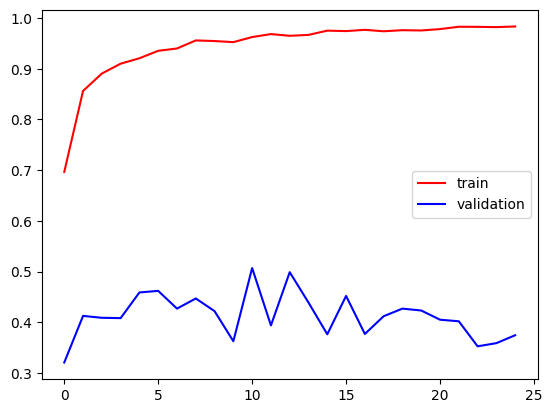

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

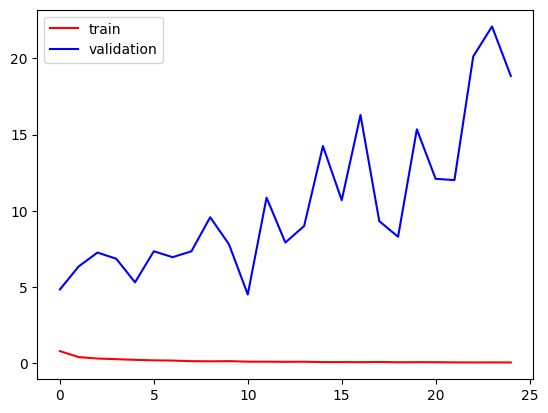

In [18]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from keras.models import load_model

In [20]:
test_predictions = model.predict(test_images)
predicted_labels = np.argmax(test_predictions, axis = 1)
print('Classification Report:')
print(classification_report(test_labels, predicted_labels))

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       400
           1       0.54      0.67      0.60       400
           2       0.36      1.00      0.53       400
           3       1.00      0.01      0.02       400

    accuracy                           0.42      1600
   macro avg       0.48      0.42      0.29      1600
weighted avg       0.48      0.42      0.29      1600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Confusion Matrix:
[[  0 196 204   0]
 [  0 268 132   0]
 [  0   0 400   0]
 [  0  33 363   4]]


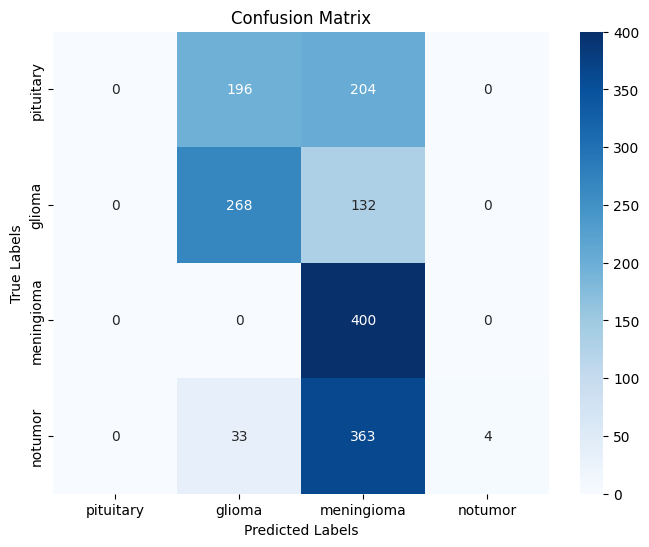

In [21]:
conf_matrix = confusion_matrix(test_labels, predicted_labels)
print("Confusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [22]:
model.save('model.keras')

In [23]:
from tensorflow.keras.models import load_model
model = load_model('model.keras')

In [25]:
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect(img_path, model, image_size=256):
  try:
    img = load_img(img_path, target_size=(image_size, image_size))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    confidence_score = np.max(predictions, axis=1)[0]

    if class_labels[predicted_class_index] == 'notumor':
        result = "No Tumor"
    else:
        result = f"Tumor: {class_labels[predicted_class_index]}"

    plt.imshow(load_img(img_path))
    plt.axis('off')
    plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
    plt.show()

  except Exception as e:
        print("Error in processing the image:", str(e))